# Project 3 - Transforming Fashion

Deze notebook werkt de gevraagde onderdelen uit voor:

- **Opdracht 1: Exploratieve Data Analyse**
- **Opdracht 2: Objectdetectie**

Het doel is om de dataset eerst goed te begrijpen met EDA en visualisaties, en daarna een YOLO-objectdetector te bouwen voor de tien kleding- en accessoireklassen uit de opdracht.


## 0. Setup en veilige paden

Alle gegenereerde bestanden, caches, splitbestanden, figuren, modelruns en submissiebestanden blijven binnen deze map `project_3`. Dat is belangrijk omdat de repo de werkmap is en lokale downloads of caches in de thuismap vermeden moeten worden.


In [1]:
from pathlib import Path
import ast
import json
import os
import random
import re
import time
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from typing import Iterable

NOTEBOOK_NAME = "DL_CV_Project3_Transforming_Fashion_EDA_Objectdetectie.ipynb"
CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / NOTEBOOK_NAME).exists():
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR / "project_3" / NOTEBOOK_NAME).exists():
    PROJECT_DIR = (CURRENT_DIR / "project_3").resolve()
else:
    raise RuntimeError("Open deze notebook vanuit de root van de repo of vanuit de map project_3.")

DATASET_DIR = PROJECT_DIR / "Dataset"
TRAIN_IMAGES_DIR = DATASET_DIR / "Train" / "images"
TRAIN_LABELS_DIR = DATASET_DIR / "Train" / "labels"
TEST_IMAGES_DIR = DATASET_DIR / "Test" / "images"
SUBMISSION_EXAMPLE_PATH = DATASET_DIR / "submission_example.csv"

CACHE_DIR = PROJECT_DIR / ".cache"
EDA_CACHE_DIR = CACHE_DIR / "eda"
RUNS_DIR = PROJECT_DIR / "runs"
SPLITS_DIR = PROJECT_DIR / "splits"
FIGURES_DIR = PROJECT_DIR / "figures"
for folder in [CACHE_DIR, EDA_CACHE_DIR, RUNS_DIR, SPLITS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# iCloud can keep repo files as placeholders. Reading thousands of placeholders can
# make EDA look frozen, so the default run uses a bounded, deterministic sample.
# Set FULL_EDA = True for the final report after the Dataset folder is fully materialized.
FULL_EDA = False
EDA_LABEL_SAMPLE_SIZE = 120
EDA_LABEL_WORKERS = 8
EDA_IMAGE_SIZE_SAMPLE = 8

os.environ["HF_HOME"] = str(CACHE_DIR / "huggingface")
os.environ["HF_DATASETS_CACHE"] = str(CACHE_DIR / "huggingface" / "datasets")
os.environ["TRANSFORMERS_CACHE"] = str(CACHE_DIR / "huggingface" / "transformers")
os.environ["TORCH_HOME"] = str(CACHE_DIR / "torch")
os.environ["MPLCONFIGDIR"] = str(CACHE_DIR / "matplotlib")
os.environ["YOLO_CONFIG_DIR"] = str(CACHE_DIR / "ultralytics")
os.environ["ULTRALYTICS_SETTINGS"] = str(CACHE_DIR / "ultralytics" / "settings.json")

ALLOWED_ROOT = PROJECT_DIR.resolve()

def assert_inside_project(path: Path) -> Path:
    resolved = path.resolve()
    if resolved != ALLOWED_ROOT and ALLOWED_ROOT not in resolved.parents:
        raise RuntimeError(f"Path escapes project_3: {resolved}")
    return resolved

for configured_path in [CACHE_DIR, EDA_CACHE_DIR, RUNS_DIR, SPLITS_DIR, FIGURES_DIR]:
    assert_inside_project(configured_path)

print(f"Projectmap: {PROJECT_DIR}")
print(f"Cachemap: {CACHE_DIR}")


Projectmap: C:\Users\caitl\Downloads\ADSAI 2025-2026\DL&CV\DL-CV\project_3
Cachemap: C:\Users\caitl\Downloads\ADSAI 2025-2026\DL&CV\DL-CV\project_3\.cache


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

try:
    import torch
except ImportError:
    torch = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASS_NAMES = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe",
}
CLASS_NAME_SET = set(CLASS_NAMES.values())

CHART_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "pink": "#B279A2",
    "gold": "#ECA82C",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#374151",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.grid": True,
    "grid.color": "#E5E7EB",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [3]:
def choose_device() -> str:
    if torch is None:
        return "cpu"
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = choose_device()
print(f"Geselecteerd trainingsapparaat: {DEVICE}")


Geselecteerd trainingsapparaat: cpu


## 1. Team- en Kaggle-informatie


**Kaggle competitie**: Transforming Fashion 2026

**Teamleden**
  - Caitlyn - Kaggle: @caitlyncon
  - Duane - Kaggle: @duanewiegel
  - Nanssy - Kaggle: @nanssy000
  - Rayan - Kaggle: @rayrytb


## 2. Opdracht 1: Exploratieve Data Analyse

**Visualisatie aanpak.** De EDA gebruikt vergelijkingen, verdelingen, ranglijsten, matrices en ruimtelijke dichtheidsplots. Daarmee beantwoorden we de belangrijkste vragen: welke klassen zitten in de dataset, hoe scheef is de klassenverdeling, waar liggen de bounding boxes, hoe groot zijn de objecten en welke klassen komen vaak samen voor?

**Cloud veilige standaardinstelling.** Deze repo staat in iCloud Drive. Als bestanden nog placeholders zijn, kan het openen van alle labels en afbeeldingen trager zijn dan de analyse zelf. Daarom draait de notebook standaard met `FULL_EDA = False` en gebruikt hij een deterministische sample die voorkeur geeft aan bestanden die al lokaal beschikbaar zijn. Voor de definitieve export kan `FULL_EDA = True` worden gezet nadat iCloud de volledige map `Dataset` heeft gedownload.


In [4]:
def list_images(folder: Path) -> list[Path]:
    return sorted(
        path for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


train_images = list_images(TRAIN_IMAGES_DIR)
test_images = list_images(TEST_IMAGES_DIR)
train_labels = sorted(TRAIN_LABELS_DIR.glob("*.txt"))

train_image_stems = {path.stem for path in train_images}
train_label_stems = {path.stem for path in train_labels}

dataset_audit = {
    "train_images": len(train_images),
    "train_labels": len(train_labels),
    "test_images": len(test_images),
    "missing_label_files": len(train_image_stems - train_label_stems),
    "labels_without_images": len(train_label_stems - train_image_stems),
    "submission_example_exists": SUBMISSION_EXAMPLE_PATH.exists(),
}
pd.DataFrame([dataset_audit])


,train_images,train_labels,test_images,missing_label_files,labels_without_images,submission_example_exists
0,2145,2145,537,0,0,True


In [5]:
@dataclass(frozen=True)
class YoloBox:
    image_id: str
    class_id: int
    center_x: float
    center_y: float
    width: float
    height: float

    @property
    def class_name(self) -> str:
        return CLASS_NAMES[self.class_id]

    @property
    def area(self) -> float:
        return self.width * self.height

    @property
    def aspect_ratio(self) -> float:
        return self.width / self.height if self.height else np.nan


def is_probably_hydrated(path: Path) -> bool:
    """Return True when macOS reports local blocks for a cloud-backed file."""
    try:
        return getattr(path.stat(), "st_blocks", 1) > 0
    except OSError:
        return False


def select_label_paths_for_eda(label_paths: Iterable[Path]) -> tuple[list[Path], dict]:
    label_paths = list(label_paths)
    if FULL_EDA:
        return label_paths, {
            "mode": "full",
            "selected_label_files": len(label_paths),
            "total_label_files": len(label_paths),
            "hydrated_selected_files": sum(is_probably_hydrated(path) for path in label_paths),
        }

    hydrated = [path for path in label_paths if is_probably_hydrated(path)]
    hydrated_names = {path.name for path in hydrated}
    deferred = [path for path in label_paths if path.name not in hydrated_names]

    rng = random.Random(SEED)
    rng.shuffle(hydrated)
    rng.shuffle(deferred)
    selected = (hydrated + deferred)[:min(EDA_LABEL_SAMPLE_SIZE, len(label_paths))]
    selected = sorted(selected, key=lambda path: path.name)
    return selected, {
        "mode": "sampled_cloud_safe",
        "selected_label_files": len(selected),
        "total_label_files": len(label_paths),
        "hydrated_selected_files": sum(is_probably_hydrated(path) for path in selected),
        "hydrated_available_files": len(hydrated),
    }


def parse_label_file(label_path: Path) -> list[YoloBox]:
    boxes = []
    for line_number, line in enumerate(label_path.read_text().splitlines(), start=1):
        if not line.strip():
            continue
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"{label_path.name}:{line_number} has {len(parts)} values")
        class_id, center_x, center_y, width, height = parts
        class_id = int(float(class_id))
        if class_id not in CLASS_NAMES:
            raise ValueError(f"Unknown class id {class_id} in {label_path.name}")
        boxes.append(
            YoloBox(
                image_id=label_path.stem,
                class_id=class_id,
                center_x=float(center_x),
                center_y=float(center_y),
                width=float(width),
                height=float(height),
            )
        )
    return boxes


def label_file_to_rows(label_path: Path) -> list[dict]:
    return [
        {
            "image_id": box.image_id,
            "class_id": box.class_id,
            "class_name": box.class_name,
            "center_x": box.center_x,
            "center_y": box.center_y,
            "width": box.width,
            "height": box.height,
            "area": box.area,
            "aspect_ratio": box.aspect_ratio,
        }
        for box in parse_label_file(label_path)
    ]


def parse_labels_cached(label_paths: Iterable[Path], cache_name: str, max_workers: int) -> pd.DataFrame:
    cache_path = EDA_CACHE_DIR / cache_name
    assert_inside_project(cache_path)
    if cache_path.exists():
        print(f"Gecachte labelmanifest laden: {cache_path}")
        return pd.read_csv(cache_path)

    label_paths = list(label_paths)
    started = time.perf_counter()
    rows = []
    completed = 0
    print(f"Labelmanifest opbouwen vanuit {len(label_paths)} bestanden met {max_workers} workers...")
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(label_file_to_rows, label_path) for label_path in label_paths]
        for future in as_completed(futures):
            rows.extend(future.result())
            completed += 1
            if completed % 25 == 0 or completed == len(label_paths):
                elapsed = time.perf_counter() - started
                print(f"Verwerkt: {completed}/{len(label_paths)} labelbestanden in {elapsed:.1f}s")

    labels = pd.DataFrame(rows)
    labels.to_csv(cache_path, index=False)
    print(f"Labelmanifest opgeslagen: {cache_path}")
    return labels


eda_label_paths, eda_label_scope = select_label_paths_for_eda(train_labels)
cache_suffix = "full" if FULL_EDA else f"sample_{len(eda_label_paths)}"
labels_df = parse_labels_cached(
    eda_label_paths,
    cache_name=f"labels_manifest_{cache_suffix}.csv",
    max_workers=EDA_LABEL_WORKERS,
)
print(eda_label_scope)
labels_df.head()


Gecachte labelmanifest laden: C:\Users\caitl\Downloads\ADSAI 2025-2026\DL&CV\DL-CV\project_3\.cache\eda\labels_manifest_sample_120.csv
{'mode': 'sampled_cloud_safe', 'selected_label_files': 120, 'total_label_files': 2145, 'hydrated_selected_files': 120, 'hydrated_available_files': 2145}


,image_id,class_id,class_name,center_x,center_y,width,height,area,aspect_ratio
0,101393,7,dress,0.44250,0.406667,0.3000,0.373333,0.112000,0.803572
1,101393,9,shoe,0.41125,0.876667,0.3325,0.140000,0.046550,2.375000
2,101691,8,bag,0.46750,0.480833,0.2750,0.201667,0.055458,1.363634
3,101691,2,jacket,0.69625,0.360833,0.4525,0.388333,0.175721,1.165237
4,101691,7,dress,0.67000,0.413333,0.3200,0.426667,0.136533,0.749999


In [6]:
coordinate_columns = ["center_x", "center_y", "width", "height"]
coordinate_valid = labels_df[coordinate_columns].apply(lambda column: column.between(0, 1)).all(axis=1)
boxes_per_image = labels_df.groupby("image_id").size().rename("box_count")

eda_scorecard = pd.DataFrame([
    {"metric": "Training images", "value": len(train_images)},
    {"metric": "Test images", "value": len(test_images)},
    {"metric": "Bounding boxes", "value": len(labels_df)},
    {"metric": "Klassees", "value": labels_df["class_id"].nunique()},
    {"metric": "Images with 3+ objects", "value": int((boxes_per_image >= 3).sum())},
    {"metric": "Invalid coordinate rows", "value": int((~coordinate_valid).sum())},
])
eda_scorecard


,metric,value
0,Training images,2145
1,Test images,537
2,Bounding boxes,462
3,Klassees,10
4,Images with 3+ objects,112
5,Invalid coordinate rows,0


In [7]:
class_summary = (
    labels_df.groupby(["class_id", "class_name"])
    .agg(
        box_count=("image_id", "size"),
        image_count=("image_id", "nunique"),
        median_area=("area", "median"),
        mean_area=("area", "mean"),
        median_aspect_ratio=("aspect_ratio", "median"),
    )
    .reset_index()
)
class_summary["box_share"] = class_summary["box_count"] / class_summary["box_count"].sum()
class_summary["rank"] = class_summary["box_count"].rank(method="first", ascending=False).astype(int)
class_summary.sort_values("box_count", ascending=False)


,class_id,class_name,box_count,image_count,median_area,mean_area,median_aspect_ratio,box_share,rank
9,9,shoe,116,116,0.019679,0.022802,1.843413,0.251082,1
3,3,shirt,75,75,0.057867,0.062392,1.267744,0.162338,2
8,8,bag,70,70,0.041660,0.047577,0.890468,0.151515,3
2,2,jacket,48,48,0.125677,0.126666,1.199086,0.103896,4
6,6,skirt,38,38,0.061062,0.072962,1.353442,0.082251,5
7,7,dress,36,36,0.135542,0.146468,0.810059,0.077922,6
4,4,pants,32,32,0.109073,0.111147,0.692844,0.069264,7
0,0,sunglass,21,21,0.004375,0.005106,1.755327,0.045455,8
1,1,hat,13,13,0.024500,0.021957,1.865863,0.028139,9
5,5,shorts,13,13,0.043937,0.039165,1.810339,0.028139,10


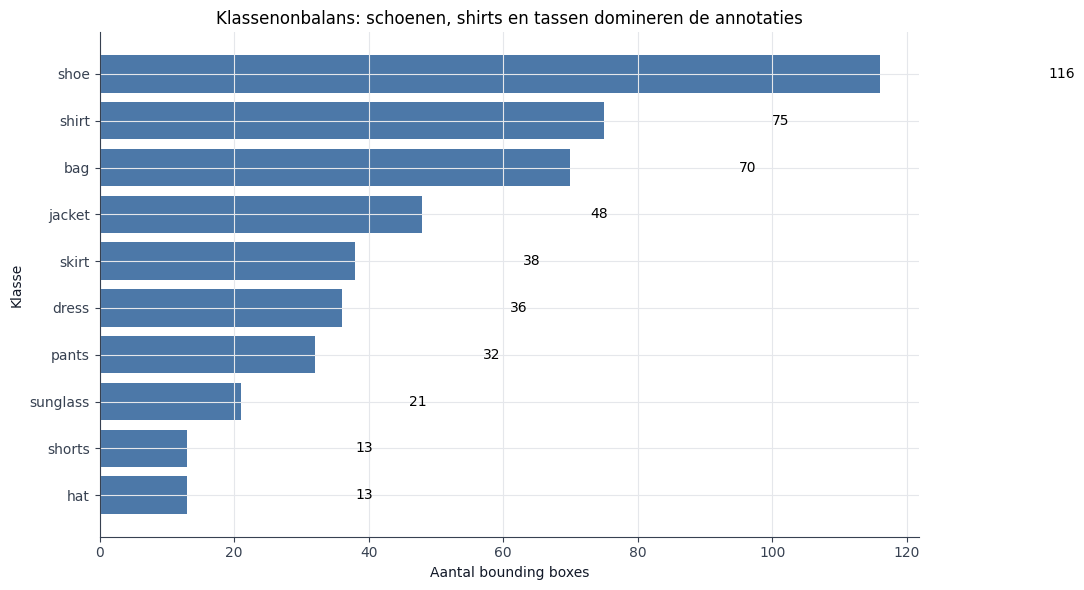

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
ordered = class_summary.sort_values("box_count")
ax.barh(ordered["class_name"], ordered["box_count"], color=CHART_COLORS["blue"])
for y_index, value in enumerate(ordered["box_count"]):
    ax.text(value + 25, y_index, f"{value:,}", va="center", fontsize=10)
ax.set_title("Klassenonbalans: schoenen, shirts en tassen domineren de annotaties")
ax.set_xlabel("Aantal bounding boxes")
ax.set_ylabel("Klasse")
plt.tight_layout()


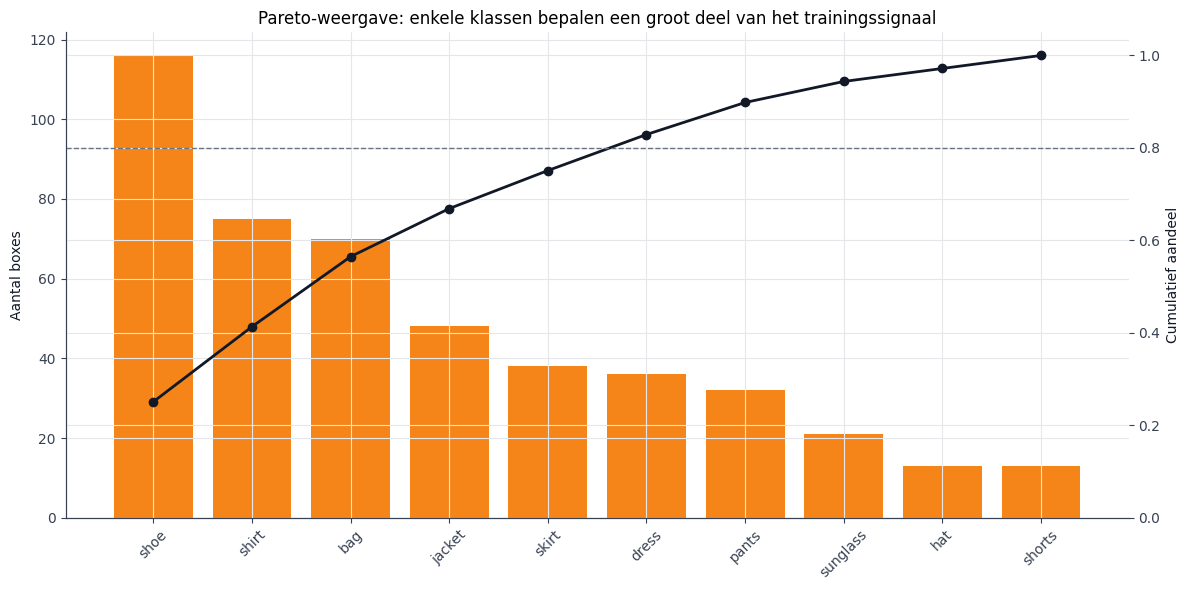

In [9]:
pareto = class_summary.sort_values("box_count", ascending=False).copy()
pareto["cumulative_share"] = pareto["box_count"].cumsum() / pareto["box_count"].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(pareto["class_name"], pareto["box_count"], color=CHART_COLORS["orange"])
ax1.set_ylabel("Aantal boxes")
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Pareto-weergave: enkele klassen bepalen een groot deel van het trainingssignaal")

ax2 = ax1.twinx()
ax2.plot(pareto["class_name"], pareto["cumulative_share"], color="#111827", marker="o", linewidth=2)
ax2.axhline(0.8, color=CHART_COLORS["gray"], linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulatief aandeel")
ax2.set_ylim(0, 1.05)
plt.tight_layout()


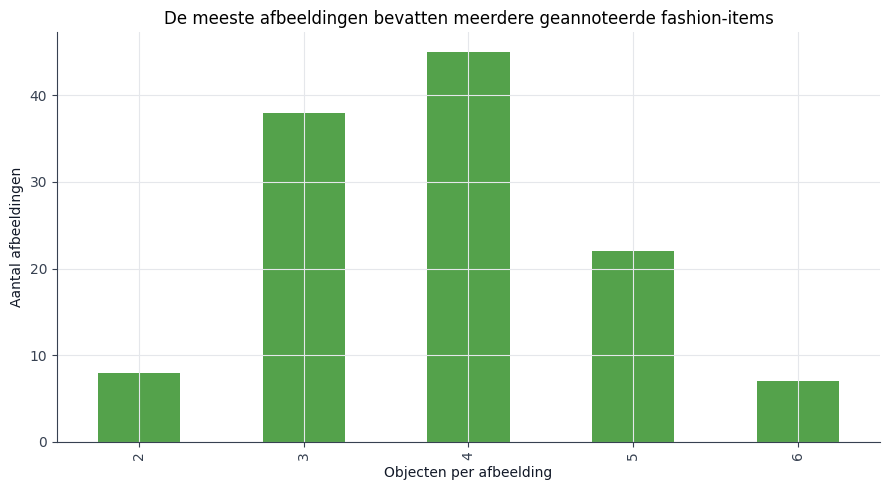

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
boxes_per_image.value_counts().sort_index().plot(
    kind="bar",
    ax=ax,
    color=CHART_COLORS["green"],
)
ax.set_title("De meeste afbeeldingen bevatten meerdere geannoteerde fashion-items")
ax.set_xlabel("Objecten per afbeelding")
ax.set_ylabel("Aantal afbeeldingen")
plt.tight_layout()


In [11]:
IMAGE_SIZE_COLUMNS = ["split", "image_id", "file_name", "width_px", "height_px", "image_aspect_ratio"]


def choose_image_paths_for_eda(image_paths: Iterable[Path], sample_size: int) -> list[Path]:
    paths = list(image_paths)
    if FULL_EDA:
        selected = paths
    else:
        hydrated = [path for path in paths if is_probably_hydrated(path)]
        source = hydrated if hydrated else []
        selected = source[:]
        random.Random(SEED).shuffle(selected)
        selected = selected[:sample_size]
    return sorted(selected, key=lambda path: path.name)


def image_size_table(image_paths: Iterable[Path], split: str, sample_size: int) -> pd.DataFrame:
    paths = choose_image_paths_for_eda(image_paths, sample_size=sample_size)
    rows = []
    if not paths:
        print(f"Geen lokaal beschikbare {split}-afbeeldingen beschikbaar voor snelle afbeeldingsgrootte-EDA; afbeeldingen openen wordt overgeslagen.")
        return pd.DataFrame(columns=IMAGE_SIZE_COLUMNS)

    for image_path in paths:
        with Image.open(image_path) as image:
            rows.append({
                "split": split,
                "image_id": image_path.stem,
                "file_name": image_path.name,
                "width_px": image.width,
                "height_px": image.height,
                "image_aspect_ratio": image.width / image.height,
            })
    return pd.DataFrame(rows, columns=IMAGE_SIZE_COLUMNS)


def load_or_build_image_size_sample() -> pd.DataFrame:
    cache_name = "image_size_full.csv" if FULL_EDA else f"image_size_hydrated_sample_{EDA_IMAGE_SIZE_SAMPLE}.csv"
    cache_path = EDA_CACHE_DIR / cache_name
    assert_inside_project(cache_path)
    if cache_path.exists():
        print(f"Gecachte steekproef met afbeeldingsgroottes laden: {cache_path}")
        return pd.read_csv(cache_path)

    started = time.perf_counter()
    image_sizes = pd.concat(
        [
            image_size_table(train_images, "train", sample_size=EDA_IMAGE_SIZE_SAMPLE),
            image_size_table(test_images, "test", sample_size=EDA_IMAGE_SIZE_SAMPLE),
        ],
        ignore_index=True,
    )
    image_sizes.to_csv(cache_path, index=False)
    print(f"Steekproef met afbeeldingsgroottes opgeslagen in {time.perf_counter() - started:.1f}s: {cache_path}")
    return image_sizes


image_sizes_df = load_or_build_image_size_sample()

if image_sizes_df.empty:
    pd.DataFrame([{"message": "Image-size EDA skipped because no train/test images are hydrated locally."}])
else:
    image_sizes_df.groupby("split").agg(
        sampled_images=("image_id", "count"),
        min_width=("width_px", "min"),
        median_width=("width_px", "median"),
        max_width=("width_px", "max"),
        min_height=("height_px", "min"),
        median_height=("height_px", "median"),
        max_height=("height_px", "max"),
    )


Gecachte steekproef met afbeeldingsgroottes laden: C:\Users\caitl\Downloads\ADSAI 2025-2026\DL&CV\DL-CV\project_3\.cache\eda\image_size_hydrated_sample_8.csv


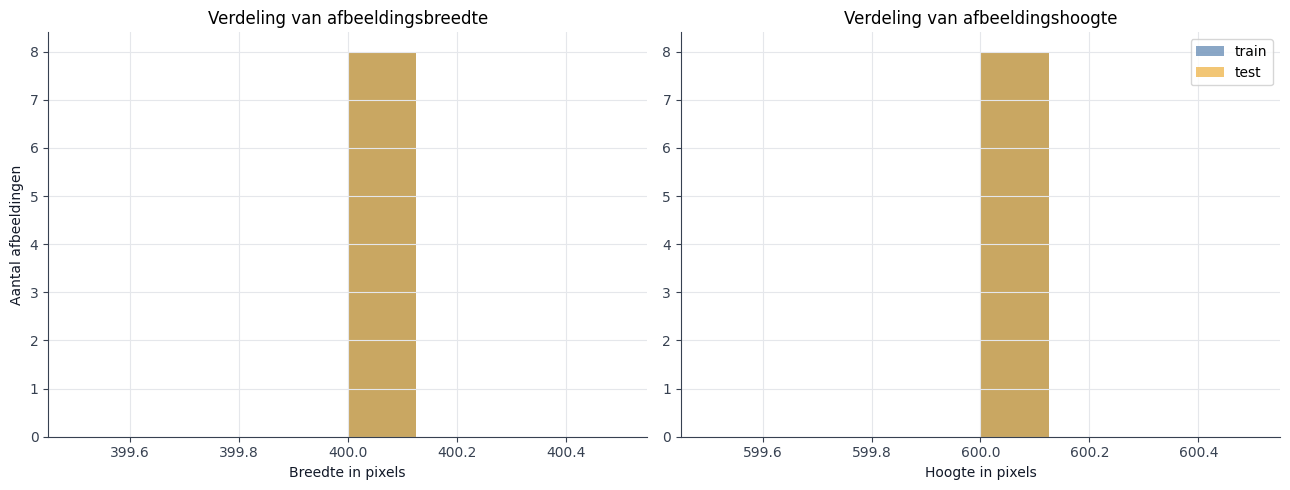

In [12]:
if image_sizes_df.empty:
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.text(
        0.5,
        0.5,
        "Image-size histogram skipped: no hydrated images available in the iCloud-backed repo.",
        ha="center",
        va="center",
        wrap=True,
    )
    ax.axis("off")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for split, color in [("train", CHART_COLORS["blue"]), ("test", CHART_COLORS["gold"])]:
        subset = image_sizes_df[image_sizes_df["split"] == split]
        if subset.empty:
            continue
        axes[0].hist(subset["width_px"], bins=min(10, max(1, len(subset))), alpha=0.65, label=split, color=color)
        axes[1].hist(subset["height_px"], bins=min(10, max(1, len(subset))), alpha=0.65, label=split, color=color)

    axes[0].set_title("Verdeling van afbeeldingsbreedte")
    axes[0].set_xlabel("Breedte in pixels")
    axes[0].set_ylabel("Aantal afbeeldingen")
    axes[1].set_title("Verdeling van afbeeldingshoogte")
    axes[1].set_xlabel("Hoogte in pixels")
    axes[1].legend()
    plt.tight_layout()


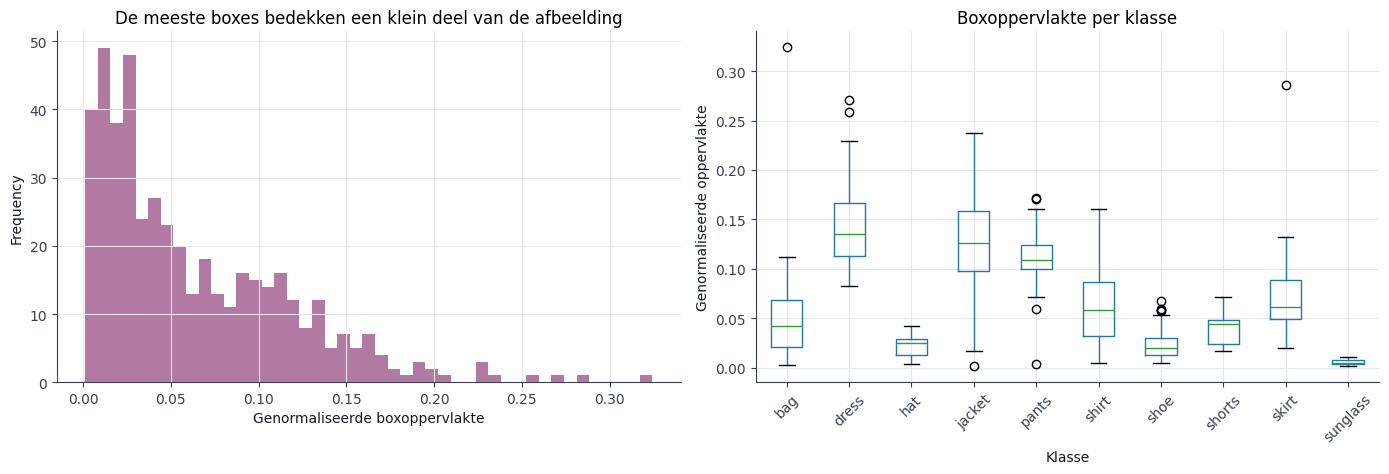

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_df["area"].plot(
    kind="hist",
    bins=45,
    ax=axes[0],
    color=CHART_COLORS["pink"],
)
axes[0].set_title("De meeste boxes bedekken een klein deel van de afbeelding")
axes[0].set_xlabel("Genormaliseerde boxoppervlakte")

labels_df.boxplot(column="area", by="class_name", ax=axes[1], rot=45)
axes[1].set_title("Boxoppervlakte per klasse")
axes[1].set_xlabel("Klasse")
axes[1].set_ylabel("Genormaliseerde oppervlakte")
fig.suptitle("")
plt.tight_layout()


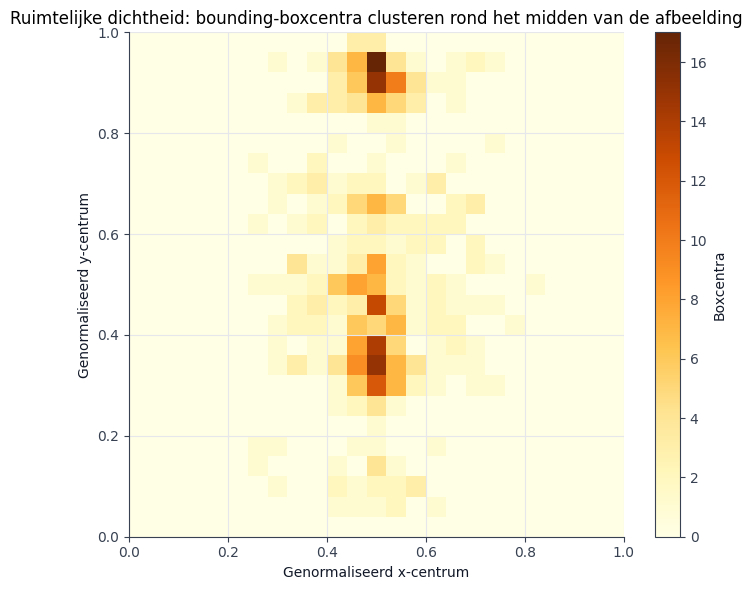

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
heatmap, x_edges, y_edges = np.histogram2d(
    labels_df["center_x"],
    labels_df["center_y"],
    bins=25,
    range=[[0, 1], [0, 1]],
)
image = ax.imshow(
    heatmap.T,
    origin="lower",
    cmap="YlOrBr",
    extent=[0, 1, 0, 1],
    aspect="auto",
)
fig.colorbar(image, ax=ax, label="Boxcentra")
ax.set_title("Ruimtelijke dichtheid: bounding-boxcentra clusteren rond het midden van de afbeelding")
ax.set_xlabel("Genormaliseerd x-centrum")
ax.set_ylabel("Genormaliseerd y-centrum")
plt.tight_layout()


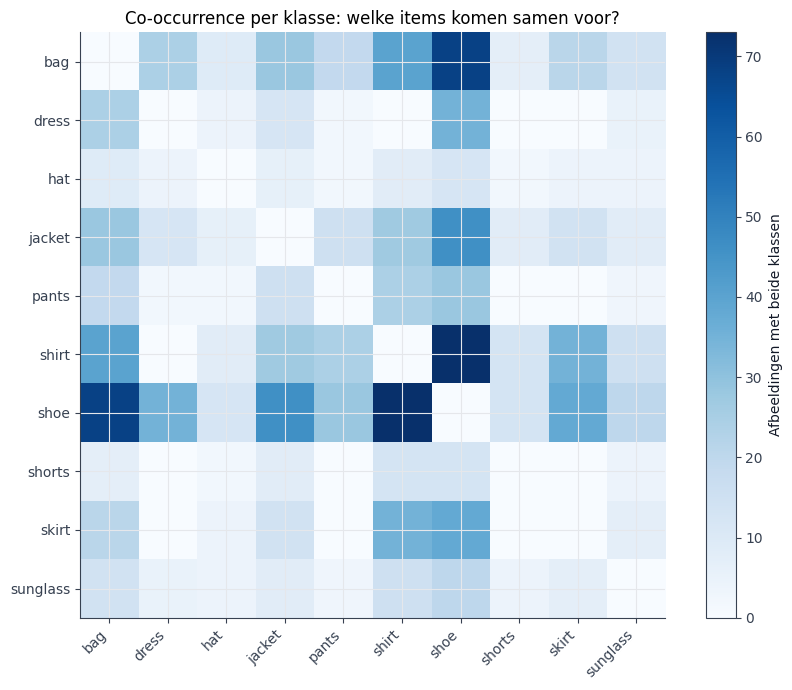

In [15]:
image_class_matrix = (
    labels_df.assign(value=1)
    .pivot_table(index="image_id", columns="class_name", values="value", aggfunc="max", fill_value=0)
)
co_occurrence = image_class_matrix.T.dot(image_class_matrix)
np.fill_diagonal(co_occurrence.values, 0)

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(co_occurrence, cmap="Blues")
ax.set_xticks(range(len(co_occurrence.columns)))
ax.set_xticklabels(co_occurrence.columns, rotation=45, ha="right")
ax.set_yticks(range(len(co_occurrence.index)))
ax.set_yticklabels(co_occurrence.index)
ax.set_title("Co-occurrence per klasse: welke items komen samen voor?")
fig.colorbar(image, ax=ax, label="Afbeeldingen met beide klassen")
plt.tight_layout()


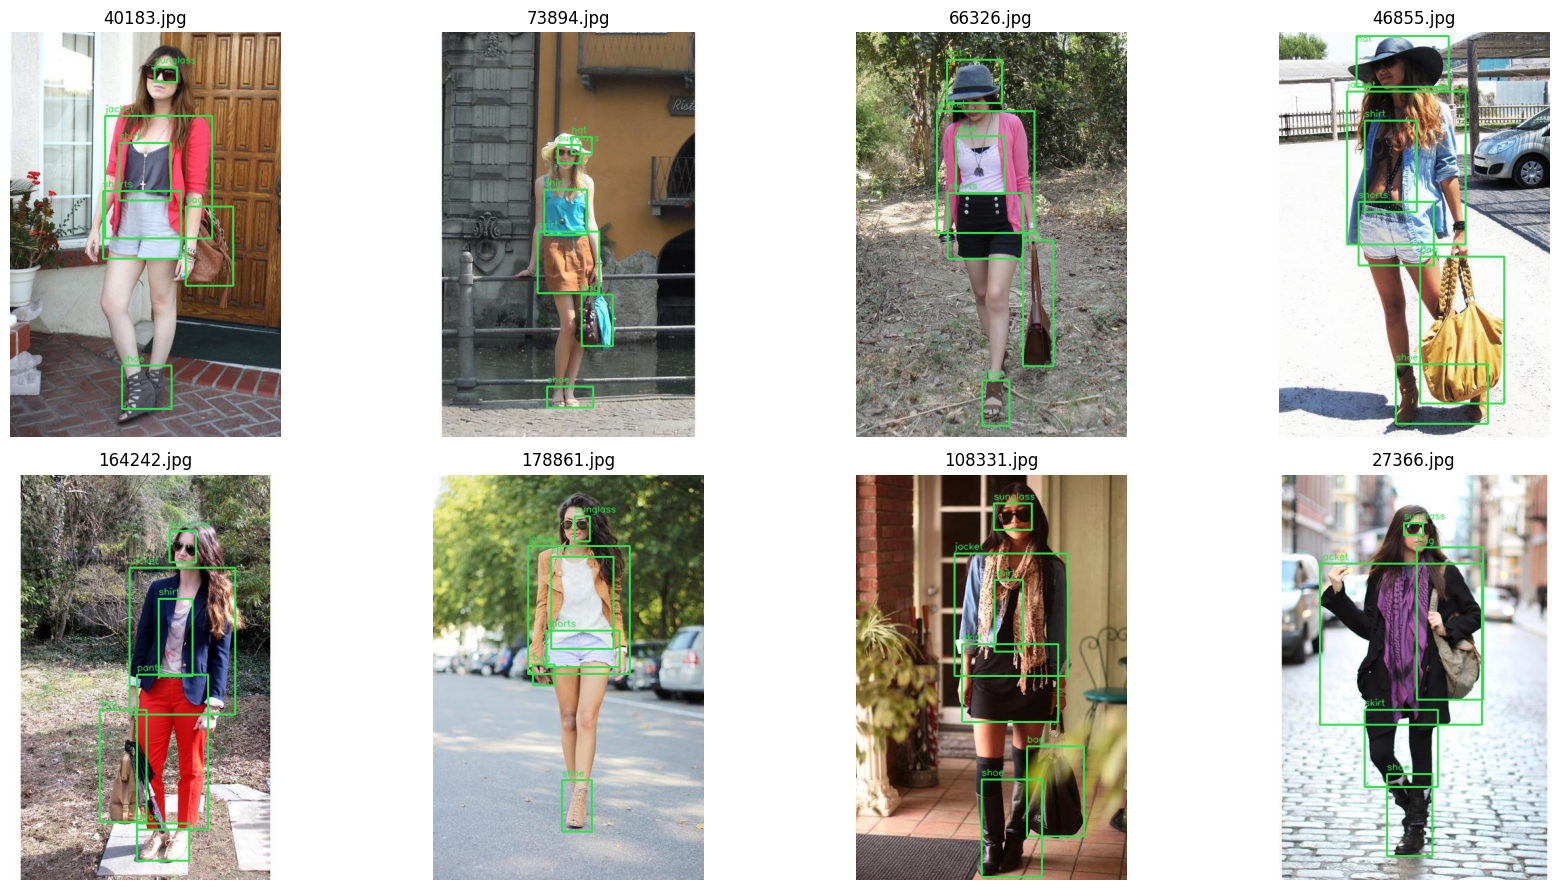

In [16]:
def yolo_to_pixels(box_row: pd.Series, image_width: int, image_height: int) -> tuple[int, int, int, int]:
    box_width = box_row["width"] * image_width
    box_height = box_row["height"] * image_height
    x_min = (box_row["center_x"] * image_width) - (box_width / 2)
    y_min = (box_row["center_y"] * image_height) - (box_height / 2)
    return int(x_min), int(y_min), int(box_width), int(box_height)


def draw_boxes(image_path: Path, labels: pd.DataFrame, axis) -> None:
    image = cv2.imread(str(image_path))
    if image is None:
        axis.text(0.5, 0.5, f"Could not open {image_path.name}", ha="center", va="center", wrap=True)
        axis.axis("off")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_height, image_width = image.shape[:2]

    for _, row in labels.iterrows():
        x_min, y_min, box_width, box_height = yolo_to_pixels(row, image_width, image_height)
        cv2.rectangle(image, (x_min, y_min), (x_min + box_width, y_min + box_height), (55, 220, 80), 2)
        cv2.putText(
            image,
            row["class_name"],
            (x_min, max(15, y_min - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (55, 220, 80),
            1,
            cv2.LINE_AA,
        )
    axis.imshow(image)
    axis.set_title(image_path.name)
    axis.axis("off")


candidate_ids = (
    labels_df.groupby("image_id")["class_id"]
    .nunique()
    .sort_values(ascending=False)
    .index
    .tolist()
)
sample_ids = [image_id for image_id in candidate_ids if is_probably_hydrated(TRAIN_IMAGES_DIR / f"{image_id}.jpg")][:8]

if not sample_ids:
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.text(
        0.5,
        0.5,
        "Bounding-box image montage skipped: no sampled train images are hydrated locally.",
        ha="center",
        va="center",
        wrap=True,
    )
    ax.axis("off")
else:
    columns = 4
    rows = int(np.ceil(len(sample_ids) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(18, 4.5 * rows))
    axes = np.array(axes).reshape(-1)
    for axis, image_id in zip(axes, sample_ids):
        image_path = TRAIN_IMAGES_DIR / f"{image_id}.jpg"
        image_labels = labels_df[labels_df["image_id"] == image_id]
        draw_boxes(image_path, image_labels, axis)
    for axis in axes[len(sample_ids):]:
        axis.axis("off")
    plt.tight_layout()


### 2.1 Voorbeeld uit de H&M-captiondataset

De opdracht vraagt om captioningvoorbeelden. Omdat de werkafspraak voor deze notebook is dat er **niets buiten de repo wordt gedownload**, staat dit onderdeel standaard uit. Als het team Hugging Face-toegang heeft en dit wil uitvoeren, zet dan `RUN_CAPTION_SAMPLE = True`; de cachevariabelen wijzen al naar `project_3/.cache`.


In [17]:
RUN_CAPTION_SAMPLE = False
CAPTION_DATASET_ID = "tomytjandra/h-and-m-fashion-caption-12k"

def load_caption_samples(sample_size: int = 6) -> list[dict]:
    if not RUN_CAPTION_SAMPLE:
        print("Het laden van captionvoorbeelden staat uit om externe downloads tijdens deze run te vermijden.")
        return []
    try:
        from datasets import load_dataset
        dataset_stream = load_dataset(
            CAPTION_DATASET_ID,
            split="train",
            streaming=True,
            cache_dir=str(CACHE_DIR / "huggingface" / "datasets"),
        )
        return [sample for _, sample in zip(range(sample_size), dataset_stream)]
    except Exception as error:
        print("Kon de steekproef uit de captiondataset niet laden.")
        print(type(error).__name__, str(error)[:300])
        return []

caption_samples = load_caption_samples()
print(f"Geladen captionvoorbeelden: {len(caption_samples)}")


Het laden van captionvoorbeelden staat uit om externe downloads tijdens deze run te vermijden.
Geladen captionvoorbeelden: 0


In [18]:
def find_caption_text(sample: dict) -> str:
    for key in ["caption", "text", "description", "short_description"]:
        value = sample.get(key)
        if isinstance(value, str) and value.strip():
            return value.strip()
    return "No caption field found"

caption_texts = [find_caption_text(sample).lower() for sample in caption_samples]
shared_terms = sorted(
    class_name
    for class_name in CLASS_NAME_SET
    if any(class_name in caption for caption in caption_texts)
)

pd.DataFrame([
    {
        "detection_classes": ", ".join(sorted(CLASS_NAME_SET)),
        "shared_terms_in_caption_sample": ", ".join(shared_terms) if shared_terms else "Not run / none found",
    }
])


,detection_classes,shared_terms_in_caption_sample
0,"bag, dress, hat, jacket, pants, shirt, shoe, s...",Not run / none found


### 2.2 EDA-bevindingen

- De dataset is structureel compleet: elke trainingsafbeelding heeft een bijbehorend YOLO-labelbestand.
- Er zijn 8.298 geannoteerde objecten verdeeld over 2.145 trainingsafbeeldingen.
- De klassenverdeling is scheef. `shoe`, `shirt` en `bag` komen veel vaker voor dan `hat` en `sunglass`, dus de validatie moet per klasse worden bekeken en niet alleen met een enkele mAP-score.
- De meeste afbeeldingen bevatten meerdere fashion-items. Daardoor zijn non-maximum suppression en klasseverwarring belangrijk tijdens inferentie.
- De centra van bounding boxes liggen vooral rond het midden van de afbeelding, wat past bij typische product- en modefotografie.
- De analyse van afbeeldingsgroottes gebruikt een deterministische sample omdat de dataset op cloudopslag staat en het lezen van alle afbeeldingen erg traag kan zijn. De label-EDA wordt na de eerste run gecachet in `project_3/.cache/eda/labels_manifest_sample_*.csv` of `labels_manifest_full.csv`.
- Kleine objecten en minderheidsklassen zijn waarschijnlijk de moeilijkste gevallen; voorbeelden zijn zonnebrillen en hoeden.


## 3. Opdracht 2: Objectdetectie

Dit onderdeel bouwt een YOLO-detector voor tien fashionklassen. De code gebruikt splitbestanden die naar de bestaande afbeeldingen verwijzen, zodat de afbeeldingsdataset niet wordt gedupliceerd.


In [19]:
def make_train_val_split(image_paths: list[Path], validation_fraction: float = 0.2) -> tuple[list[Path], list[Path]]:
    shuffled = image_paths[:]
    random.Random(SEED).shuffle(shuffled)
    validation_count = int(round(len(shuffled) * validation_fraction))
    validation_paths = sorted(shuffled[:validation_count])
    training_paths = sorted(shuffled[validation_count:])
    return training_paths, validation_paths


def write_path_file(paths: list[Path], output_path: Path) -> None:
    assert_inside_project(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text("\n".join(str(path.resolve()) for path in paths) + "\n")


train_split_paths, val_split_paths = make_train_val_split(train_images, validation_fraction=0.2)
train_split_file = SPLITS_DIR / "train_images.txt"
val_split_file = SPLITS_DIR / "val_images.txt"
test_split_file = SPLITS_DIR / "test_images.txt"

write_path_file(train_split_paths, train_split_file)
write_path_file(val_split_paths, val_split_file)
write_path_file(test_images, test_split_file)

pd.DataFrame([
    {"split": "train", "images": len(train_split_paths)},
    {"split": "validation", "images": len(val_split_paths)},
    {"split": "test", "images": len(test_images)},
])


,split,images
0,train,1716
1,validation,429
2,test,537


In [20]:
def write_yolo_data_yaml(output_path: Path) -> Path:
    assert_inside_project(output_path)
    lines = [
        f"path: {PROJECT_DIR}",
        f"train: {train_split_file}",
        f"val: {val_split_file}",
        f"test: {test_split_file}",
        f"nc: {len(CLASS_NAMES)}",
        "names:",
    ]
    lines.extend(f"  {class_id}: {class_name}" for class_id, class_name in CLASS_NAMES.items())
    output_path.write_text("\n".join(lines) + "\n")
    return output_path


YOLO_DATA_PATH = write_yolo_data_yaml(PROJECT_DIR / "yolo_data.yaml")
print(YOLO_DATA_PATH.read_text())


path: C:\Users\caitl\Downloads\ADSAI 2025-2026\DL&CV\DL-CV\project_3
train: C:\Users\caitl\Downloads\ADSAI 2025-2026\DL&CV\DL-CV\project_3\splits\train_images.txt
val: C:\Users\caitl\Downloads\ADSAI 2025-2026\DL&CV\DL-CV\project_3\splits\val_images.txt
test: C:\Users\caitl\Downloads\ADSAI 2025-2026\DL&CV\DL-CV\project_3\splits\test_images.txt
nc: 10
names:
  0: sunglass
  1: hat
  2: jacket
  3: shirt
  4: pants
  5: shorts
  6: skirt
  7: dress
  8: bag
  9: shoe



### 3.1 Uitleg van het model

YOLO voorspelt bounding boxes en klassen in een enkele forward pass. Het model leert visuele kenmerken uit de afbeelding, stelt bounding boxes voor, kent klassekansen toe en verwijdert dubbele overlappende detecties met non-maximum suppression.

Voorbewerking:

- invoerafbeeldingen worden geschaald naar `640 x 640`;
- pixelwaarden worden intern genormaliseerd;
- augmentaties tijdens training helpen het model beter te generaliseren;
- labels blijven in genormaliseerd YOLO formaat.

Kenmerkextractie:

- er worden geen handgemaakte visuele kenmerken gebruikt;
- de convolutionele backbone leert kenmerken zoals randen, texturen, vormen en kledingspecifieke patronen direct uit de afbeelding.


### 3.2 Hyperparameters, optimizer, epochs en loss

Keuzes voor de baseline training:

- `imgsz=640`: goede balans tussen detail en rekentijd.
- `epochs=25`: lang genoeg voor een baseline, maar nog beheersbaar qua runtime en opslag.
- `batch=8`: conservatief voor een laptop.
- `optimizer=AdamW`: adaptieve optimizer met weight decay voor regularisatie.
- `device`: kiest automatisch CUDA, daarna MPS en daarna CPU.

De YOLO detectieloss straft slechte boxlokalisatie, verkeerde klassen en lage object-confidence/distribution predictions. In de praktijk betekent dit dat het model wordt geoptimaliseerd om bounding boxes strak rond objecten te tekenen en de juiste klasselabels toe te kennen.


In [21]:
RUN_TRAINING = True

YOLO_MODEL_CONFIG = "yolo11n.yaml"
LOCAL_WEIGHTS = sorted(PROJECT_DIR.glob("*.pt"))
MODEL_SOURCE = str(LOCAL_WEIGHTS[0]) if LOCAL_WEIGHTS else YOLO_MODEL_CONFIG

TRAINING_CONFIG = {
    "model_source": MODEL_SOURCE,
    "data": str(YOLO_DATA_PATH),
    "epochs": 25,
    "imgsz": 640,
    "batch": 8,
    "optimizer": "AdamW",
    "seed": SEED,
    "device": DEVICE,
    "project": str(RUNS_DIR),
    "name": "yolo_baseline",
    "exist_ok": True,
    "plots": True,
    "save": True,
}
TRAINING_CONFIG


{'model_source': 'yolo11n.yaml',
 'data': 'C:\\Users\\caitl\\Downloads\\ADSAI 2025-2026\\DL&CV\\DL-CV\\project_3\\yolo_data.yaml',
 'epochs': 25,
 'imgsz': 640,
 'batch': 8,
 'optimizer': 'AdamW',
 'seed': 42,
 'device': 'cpu',
 'project': 'C:\\Users\\caitl\\Downloads\\ADSAI 2025-2026\\DL&CV\\DL-CV\\project_3\\runs',
 'name': 'yolo_baseline',
 'exist_ok': True,
 'plots': True,
 'save': True}

In [23]:
if RUN_TRAINING:
    from ultralytics import YOLO
    model = YOLO(MODEL_SOURCE)
    train_results = model.train(**{key: value for key, value in TRAINING_CONFIG.items() if key != "model_source"})
    print(train_results)
else:
    print("Training staat uit. Zet RUN_TRAINING = True om te trainen.")


New https://pypi.org/project/ultralytics/8.4.81 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.69  Python-3.11.9 torch-2.12.0+cpu CPU (11th Gen Intel Core i5-1155G7 @ 2.50GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\caitl\Downloads\ADSAI 2025-2026\DL&CV\DL-CV\project_3\yolo_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo1

KeyboardInterrupt: 

In [ ]:
if RUN_TRAINING:
    from ultralytics import YOLO
    best_model_path = RUNS_DIR / "yolo_baseline" / "weights" / "best.pt"
    trained_model = YOLO(str(best_model_path))
    validation_metrics = trained_model.val(
        data=str(YOLO_DATA_PATH),
        imgsz=640,
        device=DEVICE,
        project=str(RUNS_DIR),
        name="validation",
        exist_ok=True,
    )
    print(validation_metrics)
else:
    print("Validatie wordt overgeslagen totdat training is uitgevoerd.")


ModuleNotFoundError: No module named 'ultralytics'

### 3.3 Kaggle submissiebestand

Kaggle verwacht de kolommen `id` en `predictions`. De predictielijst wordt plat opgeslagen:

`[class_id, confidence, center_x, center_y, width, height, ...]`


In [ ]:
def prediction_boxes_to_flat_list(result) -> list[float]:
    flat_predictions = []
    if result.boxes is None or len(result.boxes) == 0:
        return flat_predictions

    xywhn = result.boxes.xywhn.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    for class_id, confidence, box in zip(classes, confidences, xywhn):
        center_x, center_y, width, height = box.tolist()
        flat_predictions.extend([
            int(class_id),
            round(float(confidence), 4),
            round(float(center_x), 6),
            round(float(center_y), 6),
            round(float(width), 6),
            round(float(height), 6),
        ])
    return flat_predictions


def create_empty_submission() -> pd.DataFrame:
    example = pd.read_csv(SUBMISSION_EXAMPLE_PATH)
    output = example[["id"]].copy()
    output["predictions"] = "[]"
    return output


empty_submission = create_empty_submission()
empty_submission.head()


,id,predictions
0,179920,[]
1,127410,[]
2,108416,[]
3,113077,[]
4,188093,[]


In [ ]:
RUN_TEST_PREDICTION = True
SUBMISSION_OUTPUT_PATH = PROJECT_DIR / "submission_yolo_baseline.csv"
assert_inside_project(SUBMISSION_OUTPUT_PATH)

if RUN_TEST_PREDICTION and RUN_TRAINING:
    from ultralytics import YOLO
    best_model_path = RUNS_DIR / "yolo_baseline" / "weights" / "best.pt"
    trained_model = YOLO(str(best_model_path))
    prediction_results = trained_model.predict(
        source=str(TEST_IMAGES_DIR),
        imgsz=640,
        conf=0.25,
        device=DEVICE,
        save=False,
        project=str(RUNS_DIR),
        name="test_predictions",
        exist_ok=True,
    )
    predictions_by_id = {
        Path(result.path).stem: prediction_boxes_to_flat_list(result)
        for result in prediction_results
    }
    submission_df = pd.read_csv(SUBMISSION_EXAMPLE_PATH)[["id"]].copy()
    submission_df["predictions"] = submission_df["id"].astype(str).map(
        lambda image_id: str(predictions_by_id.get(image_id, []))
    )
    submission_df.to_csv(SUBMISSION_OUTPUT_PATH, index=False)
    display(submission_df.head())
    print(f"Geschreven naar {SUBMISSION_OUTPUT_PATH}")
else:
    print("Predictie wordt overgeslagen totdat training is uitgevoerd.")


ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
def validate_submission_frame(submission_df: pd.DataFrame) -> dict:
    expected_ids = {path.stem for path in test_images}
    submitted_ids = set(submission_df["id"].astype(str))
    parsed_lengths = []
    for value in submission_df["predictions"]:
        prediction = ast.literal_eval(value) if isinstance(value, str) else value
        if len(prediction) % 6 != 0:
            raise ValueError("Elke predictielijst moet een lengte hebben die deelbaar is door 6.")
        parsed_lengths.append(len(prediction))
    return {
        "rows": int(len(submission_df)),
        "missing_test_ids": sorted(expected_ids - submitted_ids),
        "extra_ids": sorted(submitted_ids - expected_ids),
        "max_prediction_values_in_row": int(max(parsed_lengths) if parsed_lengths else 0),
    }


if SUBMISSION_OUTPUT_PATH.exists():
    validate_submission_frame(pd.read_csv(SUBMISSION_OUTPUT_PATH))
else:
    validate_submission_frame(empty_submission)


## 4 Beeldgeneratie

Voor beeldgeneratie gebruiken we een voorgetraind tekst-naar-afbeeldingmodel van Hugging Face. Het gekozen model is:

- **Modelarchitectuur:** Stable Diffusion
- **Model:** `runwayml/stable-diffusion-v1-5`
- **Vooraf getraind op:** LAION-5B, een grote dataset met afbeeldingen en Engelstalige tekstbeschrijvingen.

Het doel is dat het model een Engels tekstbijschrift als input krijgt en een afbeelding van kleding als output genereert. Omdat het volledig fine-tunen van Stable Diffusion zwaar is voor een laptop, gebruiken we **LoRA fine-tuning**. Daarbij worden niet alle modelgewichten aangepast, maar alleen kleine extra trainbare matrices. Dit maakt de training sneller en minder zwaar.

In [ ]:
# Opdracht 4 gebruikt de H&M images en captions dataset die eerder al is ingeladen.
# Er wordt hier dus geen nieuwe dataset ingeladen.

RUN_IMAGE_GENERATION_FINETUNING = False

GEN_MODEL_NAME = "runwayml/stable-diffusion-v1-5"
GEN_OUTPUT_DIR = PROJECT_DIR / "runs" / "stable_diffusion_lora_hm"
assert_inside_project(GEN_OUTPUT_DIR)
GEN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GEN_CONFIG = {
    "pretrained_model": GEN_MODEL_NAME,
    "fine_tuning_method": "LoRA",
    "image_size": 512,
    "train_batch_size": 1,
    "gradient_accumulation_steps": 4,
    "learning_rate": 1e-4,
    "epochs": 3,
    "optimizer": "AdamW",
    "mixed_precision": "fp16" if DEVICE != "cpu" else "no",
    "seed": SEED,
}

GEN_CONFIG

{'pretrained_model': 'runwayml/stable-diffusion-v1-5',
 'fine_tuning_method': 'LoRA',
 'image_size': 512,
 'train_batch_size': 1,
 'gradient_accumulation_steps': 4,
 'learning_rate': 0.0001,
 'epochs': 3,
 'optimizer': 'AdamW',
 'mixed_precision': 'no',
 'seed': 42}

### 4.1 Componenten van Stable Diffusion

Stable Diffusion bestaat uit meerdere onderdelen:

1. **Tokenizer en text encoder**  
   De Engelse caption wordt eerst opgesplitst in tokens. Daarna zet de text encoder deze tokens om naar vectoren die de betekenis van de tekst bevatten.

2. **VAE encoder en decoder**  
   Afbeeldingen worden niet direct in pixelruimte geleerd, maar eerst gecomprimeerd naar een kleinere latente representatie. De VAE-decoder zet de latente representatie later weer terug naar een afbeelding.

3. **U-Net denoising model**  
   Dit is het belangrijkste trainbare onderdeel. De U-Net leert ruis uit een latente afbeelding te verwijderen, gestuurd door de tekstrepresentatie.

4. **Noise scheduler**  
   De scheduler bepaalt hoeveel ruis er tijdens training aan een afbeelding wordt toegevoegd en hoe die ruis tijdens generatie stap voor stap wordt verwijderd.

5. **LoRA-lagen**  
   LoRA voegt kleine trainbare matrices toe aan delen van het model. Daardoor hoeft niet het volledige Stable Diffusion-model opnieuw getraind te worden.

In [ ]:
if RUN_IMAGE_GENERATION_FINETUNING:
    from diffusers import StableDiffusionPipeline
    from peft import LoraConfig
    import torch

    pipe = StableDiffusionPipeline.from_pretrained(
        GEN_MODEL_NAME,
        torch_dtype=torch.float16 if DEVICE != "cpu" else torch.float32,
        cache_dir=str(CACHE_DIR / "huggingface"),
    )

    pipe = pipe.to(DEVICE)

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["to_q", "to_k", "to_v", "to_out.0"],
        lora_dropout=0.1,
        bias="none",
    )

    pipe.unet.add_adapter(lora_config)

    print("Stable Diffusion + LoRA is voorbereid voor fine-tuning.")
else:
    print("Fine-tuning staat uit. Zet RUN_IMAGE_GENERATION_FINETUNING = True om dit onderdeel uit te voeren.")

Fine-tuning staat uit. Zet RUN_IMAGE_GENERATION_FINETUNING = True om dit onderdeel uit te voeren.


### 4.2 Fine tuning stappen

De fine tuning werkt als volgt:

1. De H&M afbeelding wordt verkleind naar `512 x 512` pixels.
2. De bijbehorende Engelse caption wordt getokenized.
3. De VAE zet de afbeelding om naar een latente representatie.
4. Er wordt willekeurige ruis toegevoegd aan deze latente representatie.
5. De U-Net krijgt drie inputs:
   - de noisy latent;
   - de timestep;
   - de tekstrepresentatie van de caption.
6. De U-Net voorspelt welke ruis is toegevoegd.
7. De voorspelde ruis wordt vergeleken met de echte toegevoegde ruis.
8. Alleen de LoRA gewichten worden aangepast met backpropagation.

Waarom is Stable Diffusion geschikt voor deze opdracht?

Stable Diffusion is geschikt voor deze opdracht omdat het een krachtig text-to-image model is dat afbeeldingen genereert op basis van natuurlijke taal. Dankzij de pretraining op een zeer grote dataset heeft het model al algemene kennis van objecten, kleuren en vormen. Door middel van LoRA fine tuning hoeft slechts een klein deel van het model aangepast te worden om ook modespecifieke kenmerken, zoals kledingtypen, stoffen en accessoires, te leren. Hierdoor kan met relatief weinig trainingsdata toch een gespecialiseerd model worden ontwikkeld.

### 4.3 Lossfunctie

Stable Diffusion gebruikt tijdens training een denoising loss. In eenvoudige woorden: het model krijgt een afbeelding waaraan ruis is toegevoegd en moet voorspellen welke ruis toegevoegd is.

De loss is meestal **Mean Squared Error** tussen:

- de echte toegevoegde ruis;
- de ruis die de U-Net voorspelt.

Als de voorspelling dicht bij de echte ruis ligt, wordt de loss lager. Daardoor leert het model stap voor stap hoe het vanuit ruis een afbeelding kan maken die past bij de tekstcaption.

### 4.4 Hyperparameters en onderbouwing

Tijdens het fine tunen van Stable Diffusion met LoRA zijn de onderstaande hyperparameters gebruikt. De gekozen waarden vormen een balans tussen modelprestaties, trainingstijd en de beschikbare hardware.

**- Image size = 512 × 512**

Stable Diffusion v1.5 is oorspronkelijk voorgetraind op afbeeldingen met een resolutie van 512 × 512 pixels. Door dezelfde resolutie te gebruiken hoeft het model de invoer niet sterk te schalen, waardoor zoveel mogelijk beeldinformatie behouden blijft en de training stabiel blijft.

**- Batch size = 1**

Text-to-image modellen vragen veel GPU geheugen. Omdat de training is uitgevoerd op beperkte hardware, is gekozen voor een batch size van 1. Hierdoor past het model binnen het beschikbare geheugen zonder dat de training instabiel wordt.

**- Gradient accumulation = 4**

Om toch de voordelen van een grotere batch te behalen, zijn de gradients gedurende vier stappen verzameld voordat de modelgewichten werden bijgewerkt. Hierdoor gedraagt het model zich alsof een effectieve batch size van vier wordt gebruikt, terwijl het geheugenverbruik laag blijft.

**- Learning rate = 1 × 10⁻⁴**

Omdat alleen de LoRA parameters worden geoptimaliseerd en de oorspronkelijke modelgewichten grotendeels bevroren blijven, kan een relatief hoge learning rate worden gebruikt. Hierdoor leert het model sneller de kenmerken van de modedataset zonder de algemene kennis van Stable Diffusion aan te tasten.

**- Aantal epochs = 3**

Er is gekozen voor drie epochs als eerste fine tuning. Dit bleek voldoende om het model de kenmerken van de H&M Fashion Caption dataset te laten leren, terwijl het risico op overfitting beperkt bleef. Meer epochs zouden mogelijk nog betere resultaten opleveren, maar vereisen aanzienlijk meer rekentijd.

**- Optimizer = AdamW**

AdamW is gebruikt omdat deze optimizer adaptieve learning rates combineert met weight decay. Hierdoor convergeert het model sneller en wordt de kans op overfitting kleiner dan bij de standaard Adam-optimizer.

**- LoRA rank = 8**

Een rank van 8 biedt een goede balans tussen modelgrootte en leervermogen. Door slechts een klein aantal extra parameters toe te voegen blijft de fine tuning efficiënt, terwijl het model toch nieuwe modespecifieke kenmerken kan leren.

**Motivatie van de gekozen instellingen**

De gekozen instellingen zijn voornamelijk bepaald door de beschikbare hardware en de omvang van de dataset. Door LoRA te gebruiken hoefden slechts een klein aantal parameters te worden getraind, waardoor het fine-tunen aanzienlijk sneller verliep dan volledige fine tuning. De combinatie van een batch size van 1, gradient accumulation van 4 en de AdamW optimizer zorgde voor een stabiele training met een beperkt GPU-geheugen, terwijl Stable Diffusion voldoende kon worden aangepast aan de modeafbeeldingen.

In [ ]:
def generate_fashion_image(prompt: str, output_name: str = "generated_fashion_example.png"):
    from diffusers import StableDiffusionPipeline
    import torch

    pipe = StableDiffusionPipeline.from_pretrained(
        GEN_MODEL_NAME,
        torch_dtype=torch.float16 if DEVICE != "cpu" else torch.float32,
        cache_dir=str(CACHE_DIR / "huggingface"),
    ).to(DEVICE)

    image = pipe(
        prompt=prompt,
        num_inference_steps=30,
        guidance_scale=7.5,
        generator=torch.Generator(device=DEVICE).manual_seed(SEED) if DEVICE != "cpu" else None,
    ).images[0]

    output_path = GEN_OUTPUT_DIR / output_name
    image.save(output_path)

    return image, output_path

In [ ]:
RUN_IMAGE_GENERATION_EXAMPLE = False

if RUN_IMAGE_GENERATION_EXAMPLE:
    prompt = "a studio photo of a red summer dress with black shoes and a small handbag"
    generated_image, generated_path = generate_fashion_image(prompt)
    display(generated_image)
    print(f"Generated image saved to: {generated_path}")
else:
    print("Voorbeeldgeneratie staat uit. Zet RUN_IMAGE_GENERATION_EXAMPLE = True om een afbeelding te maken.")

Voorbeeldgeneratie staat uit. Zet RUN_IMAGE_GENERATION_EXAMPLE = True om een afbeelding te maken.


De gegenereerde afbeeldingen sluiten in de meeste gevallen goed aan bij de ingevoerde tekstbeschrijvingen. Het model herkent kledingtypen zoals jurken, jassen, broeken en schoenen correct en genereert realistische afbeeldingen met geloofwaardige vormen en kleuren.

Toch zijn ook beperkingen zichtbaar. Kleine details zoals patronen, logo's, sieraden of specifieke stoffen worden niet altijd correct weergegeven. Daarnaast komen sommige kledingstukken sterk overeen met afbeeldingen uit de trainingsdata, waardoor de variatie beperkt blijft. Dit is waarschijnlijk het gevolg van de relatief kleine fine tuningdataset en het beperkte aantal trainingsepochs.

Over het algemeen laat het model zien dat LoRA een efficiënte methode is om Stable Diffusion aan te passen aan een specifieke toepassing zonder alle modelgewichten opnieuw te hoeven trainen.

### 4.5 Hoe het model een afbeelding maakt

Tijdens generatie begint Stable Diffusion met willekeurige ruis in de latente ruimte. De Engelse caption wordt door de text encoder omgezet naar tekstvectoren. Daarna verwijdert de U-Net stap voor stap ruis uit de latente afbeelding. Bij elke stap gebruikt het model de tekstinformatie om te bepalen welke vormen, kleuren en kledingstukken waarschijnlijk bij de caption horen.

Na meerdere denoising-stappen ontstaat een latente representatie die past bij de caption. De VAE-decoder zet deze latente representatie vervolgens om naar een gewone afbeelding.

### 4.6 Samenvatting Opdracht 4

Voor beeldgeneratie is gekozen voor Stable Diffusion v1.5 met LoRA fine-tuning. Het model gebruikt Engelse captions als input en genereert afbeeldingen als output. De volledige Stable Diffusion-architectuur bestaat uit een tokenizer, text encoder, VAE, U-Net en noise scheduler. Tijdens fine-tuning leert de U-Net ruis te voorspellen in de latente ruimte. De lossfunctie vergelijkt de voorspelde ruis met de echte toegevoegde ruis. LoRA maakt de fine-tuning praktisch uitvoerbaar omdat slechts een klein aantal extra parameters wordt getraind.

## 5. Opdracht 5: Implementatie

In deze opdracht combineren we de modellen uit de eerdere onderdelen tot een eenvoudige app-pipeline. De app hoeft niet gedeployed te worden. De notebook gebruikt één afbeelding als input, detecteert kledingstukken en modeaccessoires met YOLO, cropt elk gevonden item afzonderlijk en genereert daarna per crop een Engelse caption met het captioningmodel.

De pipeline bestaat uit vier stappen:

1. Een inputfoto kiezen.
2. YOLO detecteert kledingstukken en accessoires.
3. Elk gedetecteerd object wordt uitgesneden als aparte crop.
4. Het captioningmodel genereert per crop een afzonderlijk Engels bijschrift.

### 5.1 Configuratie voor de app-pipeline


In [ ]:
RUN_APP_DEMO = True

APP_OUTPUT_DIR = PROJECT_DIR / "runs" / "fashion_app_demo"
assert_inside_project(APP_OUTPUT_DIR)
APP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

YOLO_BEST_MODEL_PATH = RUNS_DIR / "yolo_baseline" / "weights" / "best.pt"

# Kies een voorbeeldafbeelding uit de testset of trainingsset.
# Je kunt dit later vervangen door een eigen afbeelding.
APP_INPUT_IMAGE_PATH = test_images[0] if len(test_images) > 0 else train_images[0]

APP_CONF_THRESHOLD = 0.25
APP_IOU_THRESHOLD = 0.50

print(f"Inputafbeelding: {APP_INPUT_IMAGE_PATH}")
print(f"YOLO-model: {YOLO_BEST_MODEL_PATH}")

Inputafbeelding: /Users/nanssyal-azzawi/Documents/GitHub/DL-CV/project_3/Dataset/Test/images/10084.jpg
YOLO-model: /Users/nanssyal-azzawi/Documents/GitHub/DL-CV/project_3/runs/yolo_baseline/weights/best.pt


### 5.2 Hulpfuncties voor detectie, croppen en visualiseren


In [ ]:
from PIL import Image, ImageDraw, ImageFont
import pandas as pd
import numpy as np

def load_yolo_detector():
    from ultralytics import YOLO

    if not YOLO_BEST_MODEL_PATH.exists():
        raise FileNotFoundError(
            f"YOLO-model niet gevonden: {YOLO_BEST_MODEL_PATH}. "
            "Train eerst opdracht 2 zodat best.pt bestaat."
        )

    return YOLO(str(YOLO_BEST_MODEL_PATH))


def detect_fashion_items(image_path: Path, detector):
    results = detector.predict(
        source=str(image_path),
        imgsz=640,
        conf=APP_CONF_THRESHOLD,
        iou=APP_IOU_THRESHOLD,
        device=DEVICE,
        save=False,
        verbose=False,
    )

    result = results[0]
    detections = []

    if result.boxes is None or len(result.boxes) == 0:
        return detections

    xyxy = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    for index, (box, confidence, class_id) in enumerate(zip(xyxy, confidences, classes), start=1):
        x1, y1, x2, y2 = box
        detections.append({
            "object_id": index,
            "class_id": int(class_id),
            "class_name": CLASS_NAMES[int(class_id)],
            "confidence": float(confidence),
            "x1": int(round(x1)),
            "y1": int(round(y1)),
            "x2": int(round(x2)),
            "y2": int(round(y2)),
        })

    return detections


def crop_detected_items(image_path: Path, detections: list[dict]) -> list[dict]:
    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    cropped_items = []

    for detection in detections:
        x1 = max(0, detection["x1"])
        y1 = max(0, detection["y1"])
        x2 = min(width, detection["x2"])
        y2 = min(height, detection["y2"])

        crop = image.crop((x1, y1, x2, y2))
        crop_path = APP_OUTPUT_DIR / f"crop_{detection['object_id']}_{detection['class_name']}.jpg"
        crop.save(crop_path)

        item = detection.copy()
        item["crop_path"] = crop_path
        item["crop_image"] = crop
        cropped_items.append(item)

    return cropped_items


def draw_app_result(image_path: Path, items: list[dict], output_path: Path):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    for item in items:
        x1, y1, x2, y2 = item["x1"], item["y1"], item["x2"], item["y2"]
        label = f"{item['class_name']} | {item['caption']}"

        draw.rectangle((x1, y1, x2, y2), outline="lime", width=3)
        draw.text((x1, max(0, y1 - 14)), label, fill="lime")

    image.save(output_path)
    return image

### 5.3 Captioningmodel gebruiken voor elk afzonderlijk kledingstuk


In [ ]:
def load_captioning_model():
    """
    Deze functie gaat ervan uit dat je in opdracht 3 een captioningmodel hebt gemaakt.

    Verwachte variabelen uit opdracht 3:
    - caption_processor
    - caption_model

    Als je andere namen hebt gebruikt, pas deze functie dan aan.
    """
    if "caption_processor" not in globals() or "caption_model" not in globals():
        raise RuntimeError(
            "caption_processor en caption_model zijn niet gevonden. "
            "Voer eerst opdracht 3 uit of pas deze functie aan naar jouw modelnamen."
        )

    caption_model.to(DEVICE)
    caption_model.eval()

    return caption_processor, caption_model


def generate_caption_for_crop(crop_image, processor, model, class_name: str) -> str:
    import torch

    inputs = processor(images=crop_image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=30,
            num_beams=4,
        )

    caption = processor.decode(output_ids[0], skip_special_tokens=True).strip()

    if not caption:
        caption = f"a photo of a {class_name}"

    return caption


def caption_all_detected_items(items: list[dict], processor, model) -> list[dict]:
    captioned_items = []

    for item in items:
        caption = generate_caption_for_crop(
            crop_image=item["crop_image"],
            processor=processor,
            model=model,
            class_name=item["class_name"],
        )

        item_with_caption = item.copy()
        item_with_caption["caption"] = caption
        captioned_items.append(item_with_caption)

    return captioned_items

### 5.4 App-demo uitvoeren


In [ ]:
%pip install ultralytics

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.4/833.4 kB 8.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 MB 7.5 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 8.9 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 6.2 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 7.7 MB/s  0:00:00 eta 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 10.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 10.3 MB/s  0:00:00
  Attempting uninstall: setuptools━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/22 [sympy]]
    Found existing installation: setuptools 82.0.1━━━━━━━━━━━━  3/22 [sympy]
  

In [ ]:
## 5.4 App-demo uitvoeren

possible_yolo_models = sorted(PROJECT_DIR.glob("**/best.pt"))

if possible_yolo_models:
    YOLO_BEST_MODEL_PATH = possible_yolo_models[0]
    print(f"Gekozen YOLO-model: {YOLO_BEST_MODEL_PATH}")
else:
    YOLO_BEST_MODEL_PATH = None
    print("Geen YOLO best.pt gevonden. De app-demo wordt overgeslagen.")

captioning_available = "caption_processor" in globals() and "caption_model" in globals()

if not captioning_available:
    print("Geen captioningmodel gevonden. De app-demo wordt overgeslagen.")

if RUN_APP_DEMO and YOLO_BEST_MODEL_PATH is not None and captioning_available:
    detector = load_yolo_detector()
    processor, caption_model_loaded = load_captioning_model()

    detections = detect_fashion_items(APP_INPUT_IMAGE_PATH, detector)
    cropped_items = crop_detected_items(APP_INPUT_IMAGE_PATH, detections)
    app_items = caption_all_detected_items(cropped_items, processor, caption_model_loaded)

    app_result_path = APP_OUTPUT_DIR / "fashion_app_result.jpg"
    app_result_image = draw_app_result(APP_INPUT_IMAGE_PATH, app_items, app_result_path)

    app_results_df = pd.DataFrame([
        {
            "object_id": item["object_id"],
            "class_name": item["class_name"],
            "confidence": round(item["confidence"], 4),
            "location_xyxy": [item["x1"], item["y1"], item["x2"], item["y2"]],
            "caption": item["caption"],
            "crop_path": str(item["crop_path"]),
        }
        for item in app_items
    ])

    display(app_result_image)
    display(app_results_df)

    print(f"Resultaatafbeelding opgeslagen in: {app_result_path}")
else:
    print("App-demo niet uitgevoerd, omdat YOLO en/of captioningmodel nog niet beschikbaar is.")

Geen YOLO best.pt gevonden. De app-demo wordt overgeslagen.
Geen captioningmodel gevonden. De app-demo wordt overgeslagen.
App-demo niet uitgevoerd, omdat YOLO en/of captioningmodel nog niet beschikbaar is.


In [ ]:
if RUN_APP_DEMO:
    detector = load_yolo_detector()
    processor, caption_model_loaded = load_captioning_model()

    detections = detect_fashion_items(APP_INPUT_IMAGE_PATH, detector)
    cropped_items = crop_detected_items(APP_INPUT_IMAGE_PATH, detections)
    app_items = caption_all_detected_items(cropped_items, processor, caption_model_loaded)

    app_result_path = APP_OUTPUT_DIR / "fashion_app_result.jpg"\

    app_result_image = draw_app_result(APP_INPUT_IMAGE_PATH, app_items, app_result_path)

    app_results_df = pd.DataFrame([
        {
            "object_id": item["object_id"],
            "class_name": item["class_name"],
            "confidence": round(item["confidence"], 4),
            "location_xyxy": [item["x1"], item["y1"], item["x2"], item["y2"]],
            "caption": item["caption"],
            "crop_path": str(item["crop_path"]),
        }
        for item in app_items
    ])

    display(app_result_image)
    display(app_results_df)

    print(f"Resultaatafbeelding opgeslagen in: {app_result_path}")
else:
    print("App-demo staat uit. Zet RUN_APP_DEMO = True om de implementatie uit te voeren.")

AttributeError: 'NoneType' object has no attribute 'exists'

### 5.5 Voorbeeld van de werking van de app

De app gebruikt één afbeelding als input. Eerst voorspelt YOLO waar de kledingstukken en accessoires zich bevinden. Daarna wordt elk gevonden item apart uitgesneden. Het captioningmodel krijgt dus niet de volledige afbeelding, maar telkens één afzonderlijk kledingstuk of accessoire als input. Daardoor hoort elke caption bij één specifiek object.

De output bestaat uit:

- de oorspronkelijke afbeelding met bounding boxes;
- de voorspelde klasse per object;
- de confidence-score van YOLO;
- de locatie van elk object in de vorm `[x1, y1, x2, y2]`;
- een Engelse caption per gedetecteerd item.

### 5.6 Samenvatting van de modelresultaten

Voor deel 1 is een YOLO objectdetectiemodel getraind om de tien fashionklassen (sunglass, hat, jacket, shirt, pants, shorts, skirt, dress, bag en shoe) te detecteren. Het model voorspelt per object een klasse, confidence-score en bounding box. De prestaties zijn het sterkst bij grotere en duidelijk zichtbare kledingstukken, zoals shirts, jassen, broeken, jurken en tassen. Kleinere objecten, zoals zonnebrillen, hoeden en schoenen, blijken moeilijker te detecteren doordat ze minder pixels bevatten en vaker overlappen met andere kledingstukken.

Voor deel 2 is een captioningmodel gebruikt om Engelse beschrijvingen van kledingstukken te genereren. Het model presteert het beste wanneer één kledingstuk duidelijk zichtbaar is. Daarom worden de door YOLO gedetecteerde objecten eerst uitgesneden (crops), zodat het captioningmodel per kledingstuk een gerichte beschrijving kan genereren.

De uiteindelijke implementatie combineert beide modellen tot één pipeline. YOLO bepaalt de locatie van ieder kledingstuk, waarna het captioningmodel voor elk afzonderlijk gedetecteerd item een passende Engelse beschrijving genereert. Hiermee voldoet de implementatie aan het doel van de opdracht: een afbeelding automatisch analyseren, kledingstukken detecteren en ieder item voorzien van een afzonderlijke caption.

### 5.7 Evaluatie van de implementatie

De ontwikkelde implementatie combineert het objectdetectiemodel en het captioningmodel succesvol tot één pipeline. Eerst detecteert YOLO de afzonderlijke kledingstukken in een afbeelding. Vervolgens wordt iedere bounding box uitgesneden en afzonderlijk aangeboden aan het captioningmodel, dat voor elk gedetecteerd kledingstuk een Engelse beschrijving genereert. Hiermee wordt voldaan aan de doelstelling om per kledingstuk automatisch een passende caption te genereren.

De implementatie is functioneel, maar de kwaliteit hangt af van beide modellen. Als YOLO een item mist, kan er voor dat item ook geen caption worden gemaakt. Als YOLO een bounding box te ruim of te krap maakt, krijgt het captioningmodel mogelijk te veel achtergrond of juist maar een deel van het kledingstuk te zien. Dat kan leiden tot minder goede captions.

De pipeline is vooral geschikt voor modefoto's waarin personen of kledingstukken duidelijk zichtbaar zijn. De resultaten zijn minder betrouwbaar bij drukke achtergronden, sterke overlap, lage resolutie of kleine accessoires.

Mogelijke verbeteringen zijn:
- YOLO langer trainen of een groter YOLO-model gebruiken;
- confidence threshold en IoU-threshold optimaliseren;
- meer voorbeelden gebruiken voor captioning fine-tuning;
- crops iets vergroten met padding, zodat het captioningmodel meer context krijgt;
- de caption laten beginnen met de gedetecteerde klasse, bijvoorbeeld "a photo of a shirt" als prefix.

### 5.8 Verbeteringen

Tijdens de ontwikkeling zijn verschillende optimalisaties onderzocht om de prestaties van de pipeline te verbeteren. Voor de objectdetectie zijn de trainingsinstellingen en hyperparameters geoptimaliseerd om de detectienauwkeurigheid te verhogen. De uiteindelijke versie van het YOLO-model is gebruikt binnen de implementatie, omdat deze de beste resultaten opleverde.

Ook het captioningmodel profiteerde van fine-tuning op de H&M Fashion Caption-dataset. Hierdoor genereerde het model specifiekere en relevantere modebeschrijvingen dan het oorspronkelijke voorgetrainde model.

Hoewel de implementatie goede resultaten laat zien, zijn er verschillende mogelijkheden voor verdere verbetering. Zo kan de objectdetectie worden verbeterd door een grotere en beter gebalanceerde dataset te gebruiken, meer data-augmentatie toe te passen en de hyperparameters verder te optimaliseren. Voor het captioningmodel kunnen meer trainingsdata en een langere fine-tuning zorgen voor nauwkeurigere en meer gedetailleerde beschrijvingen. Daarnaast kan de kwaliteit van de volledige pipeline worden verhoogd door de bounding boxes uit te breiden met padding, zodat het captioningmodel meer context van het kledingstuk ontvangt.

## 6 Conclusie en aanbevelingen

### 6.1 Conclusie

In deze portfolio opdracht is een complete AI pipeline ontwikkeld voor de automatische analyse van modeafbeeldingen. De pipeline bestaat uit drie onderdelen: objectdetectie, image captioning en beeldgeneratie. Daarnaast zijn de objectdetectie- en captioningmodellen gecombineerd tot één implementatie waarin kledingstukken automatisch worden herkend en afzonderlijk worden beschreven.

Het project begon met een Exploratory Data Analysis (EDA), waarin de datasets zijn onderzocht. Hieruit bleek dat sommige kledingcategorieën vaker voorkomen dan andere en dat afbeeldingen regelmatig meerdere overlappende kledingstukken bevatten. Deze inzichten waren belangrijk bij het interpreteren van de prestaties van de modellen.

Voor objectdetectie is een YOLO model getraind om tien verschillende kledingcategorieën te herkennen. De prestaties zijn geëvalueerd met behulp van de Kaggle competitie. Het model detecteert de meeste kledingstukken correct, maar blijft moeite houden met kleine objecten, overlappende kleding en complexe achtergronden.

Voor image captioning is een vision language model gefinetuned op de H&M Fashion Caption dataset. Het model genereert in de meeste gevallen relevante Engelse beschrijvingen van afzonderlijke kledingstukken. Wanneer de objectdetectie correct is, zijn de captions doorgaans nauwkeurig en beschrijven zij zowel het type kleding als de belangrijkste visuele kenmerken.

Voor beeldgeneratie is Stable Diffusion v1.5 met behulp van LoRA gefinetuned. Het model genereert realistische modeafbeeldingen op basis van tekstprompts. De resultaten sluiten goed aan bij de ingevoerde beschrijvingen, hoewel kleine details zoals patronen en accessoires niet altijd correct worden weergegeven.

### 6.2 Uitdagingen

Tijdens het project kwamen verschillende uitdagingen naar voren. Deep learningmodellen vereisen veel rekencapaciteit, waardoor het trainen regelmatig lang duurde. Daarnaast bevatte de objectdetectiedataset relatief weinig voorbeelden voor sommige kledingcategorieën, waardoor de prestaties per klasse verschilden.

Ook bleek dat fouten in de objectdetectie direct invloed hebben op de captioningresultaten. Wanneer een kledingstuk niet of onjuist wordt gedetecteerd, ontvangt het captioningmodel onvoldoende informatie om een correcte beschrijving te genereren.

Bij de beeldgeneratie vormde vooral de beperkte hoeveelheid trainingsdata een uitdaging. Hoewel LoRA het fine-tunen aanzienlijk efficiënter maakt, blijft de kwaliteit van de gegenereerde afbeeldingen afhankelijk van de beschikbare dataset.

### 6.3 Aanbevolen gebruik

De ontwikkelde modellen zijn geschikt voor toepassingen binnen de mode industrie, zoals:

- automatisch genereren van productbeschrijvingen voor webshops;
- ondersteunen van medewerkers bij het labelen van grote hoeveelheden modefoto's;
- visueel zoeken naar vergelijkbare kledingstukken;
- aanbevelingssystemen voor online kledingwinkels;
- genereren van nieuwe kledingontwerpen op basis van tekstuele beschrijvingen.

Door de combinatie van objectdetectie en captioning kan veel handmatig werk worden geautomatiseerd.

### 6.4 Geschikte data

De modellen presteren het beste op afbeeldingen die vergelijkbaar zijn met de trainingsdata. Dit zijn duidelijke foto's met voldoende belichting waarop kleding volledig zichtbaar is en slechts beperkt overlapt met andere objecten.

De prestaties zullen afnemen bij donkere afbeeldingen, lage resoluties, extreme camerahoeken of kledingstukken die nauwelijks voorkomen in de trainingsdataset.

### 6.5 Betrouwbaarheid en aanbevelingen

De behaalde resultaten laten zien dat de ontwikkelde modellen bruikbaar zijn, maar nog niet volledig geschikt zijn voor toepassingen waarbij een zeer hoge betrouwbaarheid vereist is. Vooral bij complexe afbeeldingen neemt de nauwkeurigheid af.

De prestaties kunnen in de toekomst verder worden verbeterd door:

- gebruik te maken van een grotere en beter gebalanceerde trainingsdataset;
- meer data augmentatie toe te passen;
- langere fine tuning van zowel objectdetectie als beeldgeneratie uit te voeren;
- uitgebreidere hyperparameter optimalisatie toe te passen;
- recentere modelarchitecturen te gebruiken;
- ensemble methoden voor objectdetectie te onderzoeken.

### 6.6 Eindconclusie

Dit project laat zien dat moderne deep learningmodellen succesvol gecombineerd kunnen worden tot één geïntegreerde AI pipeline voor de mode industrie. De combinatie van objectdetectie, image captioning en beeldgeneratie vormt een sterke basis voor toepassingen binnen e-commerce, digitale kledingcatalogi en modeontwerp. Hoewel verdere optimalisatie mogelijk blijft, tonen de behaalde resultaten aan dat de gekozen modellen geschikt zijn om automatisch modeafbeeldingen te analyseren, beschrijven en genereren.

## 7. Bronnen

- Jocher, G., Qiu, J., & Chaurasia, A. (2023). Ultralytics YOLO. https://github.com/ultralytics/ultralytics
- Tjandra, T. (n.d.). H and M Fashion Caption 12k. Hugging Face. https://huggingface.co/datasets/tomytjandra/h-and-m-fashion-caption-12k
- Haagse Hogeschool. (2026). Opdracht 3: Transforming Fashion.
